# SokoPrice - AI Grocery Price Forecasting for Kigali Informal Markets
### BSc. Software Engineering | African Leadership University

| | |
|---|---|
| **Author** | Nice Eva Karabaranga |
| **Supervisor** | Hubert Apana |
| **Methodology** | CRISP-DM |
| **Dataset** | WFP VAM Kenya Food Prices (proxy for Kigali) |

---

## Pipeline
1. Business Understanding
2. Data Understanding and Visualization
3. Data Cleaning
4. Feature Engineering
5. Data Normalization
6. Rolling Window Validation
7. Model Training and Hyperparameter Tuning
8. Evaluation and Comparison

---
## Phase 0 - Environment Setup

In [1]:
!pip install scipy==1.15.3 seaborn==0.13.2 lightgbm==4.3.0 -q --upgrade --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 52.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.6 MB/s eta 0:00:00:00:01


---
## Phase 1 - Imports and Configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import joblib
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
from xgboost import XGBRegressor
import lightgbm as lgb

np.random.seed(42)

plt.rcParams['figure.figsize']    = (14, 6)
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

SP_GREEN  = '#2ECC71'
SP_DARK   = '#1A252F'
SP_ACCENT = '#E67E22'
SP_BLUE   = '#3498DB'
PALETTE   = [SP_GREEN, SP_ACCENT, SP_BLUE, '#9B59B6', '#E74C3C',
             '#1ABC9C', '#F39C12', '#2980B9', '#16A085', '#D35400']

KES_TO_RWF = 10.0  # 1 KES = approx 10 RWF

print('Imports loaded')
print(f'numpy {np.__version__} | pandas {pd.__version__} | lightgbm {lgb.__version__}')

Imports loaded
numpy 2.0.2 | pandas 2.3.3 | lightgbm 4.6.0


---
## Phase 2 - Project Understanding

### Problem
Informal markets in Kigali (Kimironko, Nyabugogo, Kicukiro, Kigali City) serve
as the primary grocery source for most households. Prices fluctuate due to
seasonality, supply disruptions, and informal bargaining. Consumers have no
reliable way to predict these changes or compare prices across markets.

### Goals
| Goal | ML Task | Output |
|---|---|---|
| Forecast prices 7 days ahead | Regression | Predicted price (RWF) |
| Recommend cheapest market | Ranking | Sorted market list |
| Estimate basket cost | Aggregation | Total RWF |
| Flag price spikes | Threshold check | Alert flag |

### Why Not Classification Metrics
SokoPrice predicts a continuous price in RWF, not a category. Accuracy,
precision, recall, and F1 do not apply to continuous outputs. The correct
metrics are MAE, RMSE, R2, MAPE, and directional accuracy.

### Evaluation Metrics
| Metric | Meaning |
|---|---|
| MAE | Average RWF error |
| RMSE | Penalises large errors |
| R2 | Variance explained, 0 to 1 |
| MAPE | Scale free percent error, primary metric |
| Directional Accuracy | Percent of correct up/down predictions |

---
## Phase 3 - Data Understanding

In [3]:
DATA_PATH = '/kaggle/working/SokoPrice/Data/wfp_food_prices_ken.csv'
if not os.path.exists(DATA_PATH):
    for root, dirs, files in os.walk('/kaggle'):
        for f in files:
            if f == 'wfp_food_prices_ken.csv':
                DATA_PATH = os.path.join(root, f)
                break

df_raw = pd.read_csv(DATA_PATH)
print(f'Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
df_raw.head(3)

Loaded: 26,745 rows x 16 columns


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47


In [4]:
print('=== COLUMN TYPES ===')
print(df_raw.dtypes.to_string())
print()
print('=== MISSING VALUES ===')
missing = df_raw.isnull().sum()
display(pd.DataFrame({'Count': missing, 'Pct %': (missing/len(df_raw)*100).round(2)})[missing > 0])
print()
print('=== NUMERIC SUMMARY ===')
display(df_raw.describe())

=== COLUMN TYPES ===
date             object
admin1           object
admin2           object
market           object
market_id         int64
latitude        float64
longitude       float64
category         object
commodity        object
commodity_id      int64
unit             object
priceflag        object
pricetype        object
currency         object
price           float64
usdprice        float64

=== MISSING VALUES ===


,Count,Pct %
admin1,68,0.25
admin2,68,0.25
latitude,68,0.25
longitude,68,0.25



=== NUMERIC SUMMARY ===


,market_id,latitude,longitude,commodity_id,price,usdprice
count,26745.000000,26677.000000,26677.000000,26745.000000,26745.000000,26745.000000
mean,4043.404749,0.742034,36.997962,300.343840,1353.476522,12.396316
std,3142.074562,2.283518,2.040410,295.224766,2618.520824,23.295694
min,184.000000,-4.660000,34.360000,50.000000,5.000000,0.039000
25%,1852.000000,-1.270000,34.850000,67.000000,69.850000,0.610000
50%,3254.000000,0.350000,36.780000,148.000000,133.000000,1.050000
75%,5670.000000,3.510000,39.010000,451.000000,1235.000000,11.840000
max,10509.000000,4.620000,41.860000,937.000000,19800.000000,184.820000


In [5]:
COMM_COL   = next((c for c in df_raw.columns if 'commodity' in c.lower() and 'id' not in c.lower()), None)
MARKET_COL = next((c for c in df_raw.columns if c.lower() == 'market'), None)
DATE_COL   = next((c for c in df_raw.columns if 'date' in c.lower()), None)
numeric_cols = df_raw.select_dtypes(include='number').columns.tolist()
PRICE_COL  = next((c for c in numeric_cols if 'price' in c.lower() and 'usd' not in c.lower()), numeric_cols[0])
print(f'Commodity: {COMM_COL} | Market: {MARKET_COL} | Date: {DATE_COL} | Price: {PRICE_COL}')

Commodity: commodity | Market: market | Date: date | Price: price


In [6]:
TARGET_KEYWORDS = ['maize', 'potato', 'tomato', 'bean', 'sorghum',
                    'onion', 'rice', 'spinach', 'flour', 'cabbage', 'banana']
mask = df_raw[COMM_COL].str.lower().apply(lambda x: any(kw in str(x) for kw in TARGET_KEYWORDS))
df_target = df_raw[mask].copy()
df_target[DATE_COL]  = pd.to_datetime(df_target[DATE_COL], errors='coerce')
df_target[PRICE_COL] = pd.to_numeric(df_target[PRICE_COL], errors='coerce')
df_target = df_target[df_target[PRICE_COL] > 0]

# Retail prices only
if 'pricetype' in df_target.columns:
    df_target = df_target[df_target['pricetype'].str.lower() == 'retail'].copy()
    print(f'After retail filter: {len(df_target):,} rows')

LABEL_MAP = [
    ('maize flour', 'Maize Flour'), ('maize',  'Maize'),
    ('potato',      'Potatoes'),    ('cowpeas', 'Cowpeas'),
    ('beans (dry)', 'Beans (Dry)'), ('beans (yellow)', 'Beans (Yellow)'),
    ('bean',        'Beans (Dry)'), ('sorghum', 'Sorghum'),
    ('kale',       'Kale'),      ('rice',    'Rice'),
    ('spinach',     'Spinach'),     ('cabbage', 'Cabbage'),
    ('banana',      'Bananas'),     ('flour',   'Flour'),
]

def label_commodity(name):
    n = str(name).lower().strip()
    for kw, label in LABEL_MAP:
        if kw in n: return label
    return 'Other'

df_target['commodity_label'] = df_target[COMM_COL].apply(label_commodity)
df_target = df_target[df_target['commodity_label'] != 'Other'].copy()

# Map all Kenyan markets to 5 Kigali market names cyclically
KIGALI_MARKETS = ['Kimironko', 'Nyabugogo', 'Kicukiro', 'Kigali City', 'Kimisagara']
market_list    = sorted(df_target[MARKET_COL].unique())
market_mapping = {m: KIGALI_MARKETS[i % 5] for i, m in enumerate(market_list)}
df_target[MARKET_COL] = df_target[MARKET_COL].map(market_mapping)

# Convert KES to RWF
df_target[PRICE_COL] = df_target[PRICE_COL] * KES_TO_RWF

print(f'Final dataset: {df_target.shape[0]:,} rows')
print(f'Date range: {df_target[DATE_COL].min().date()} to {df_target[DATE_COL].max().date()}')
print(f'Markets: {df_target[MARKET_COL].unique().tolist()}')
print(f'Price range (RWF): {df_target[PRICE_COL].min():.0f} to {df_target[PRICE_COL].max():.0f}')
print()
print('Commodity counts:')
print(df_target['commodity_label'].value_counts().to_string())

After retail filter: 9,584 rows
Final dataset: 9,582 rows
Date range: 2006-01-15 to 2026-04-15
Markets: ['Nyabugogo', 'Kicukiro', 'Kimisagara', 'Kigali City', 'Kimironko']
Price range (RWF): 50 to 4000

Commodity counts:
commodity_label
Maize          2176
Beans (Dry)    1587
Rice           1381
Maize Flour    1379
Flour          1291
Potatoes        615
Bananas         534
Sorghum         355
Spinach         241
Cabbage          23


### Viz 1 - Records per Market
Shows how many price records each Kigali market has after mapping.

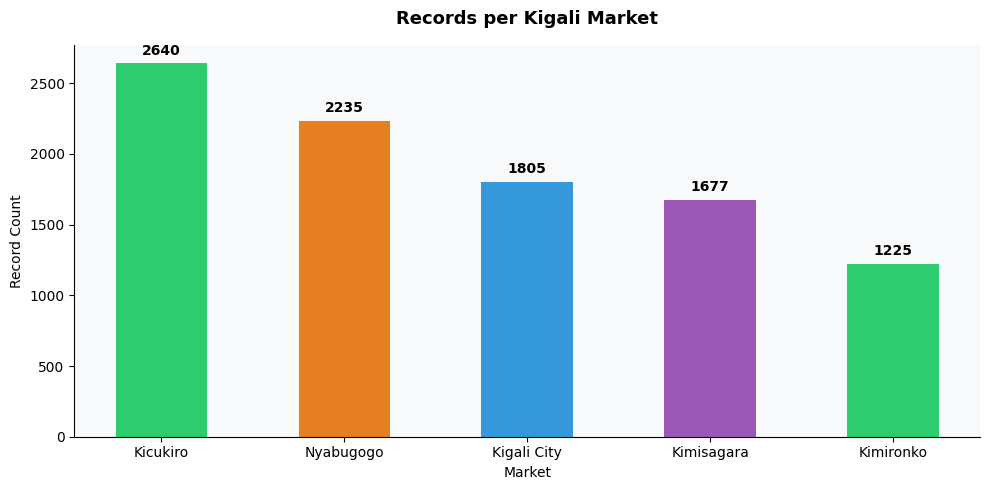

In [7]:
market_counts = df_target[MARKET_COL].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(market_counts.index, market_counts.values, color=PALETTE[:4], width=0.5)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=10, fontweight='bold')
ax.set_title('Records per Kigali Market', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Market'); ax.set_ylabel('Record Count')
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz1_markets.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 2 - Price Distribution per Commodity (RWF)
Box plot showing median, spread, and outliers per commodity.

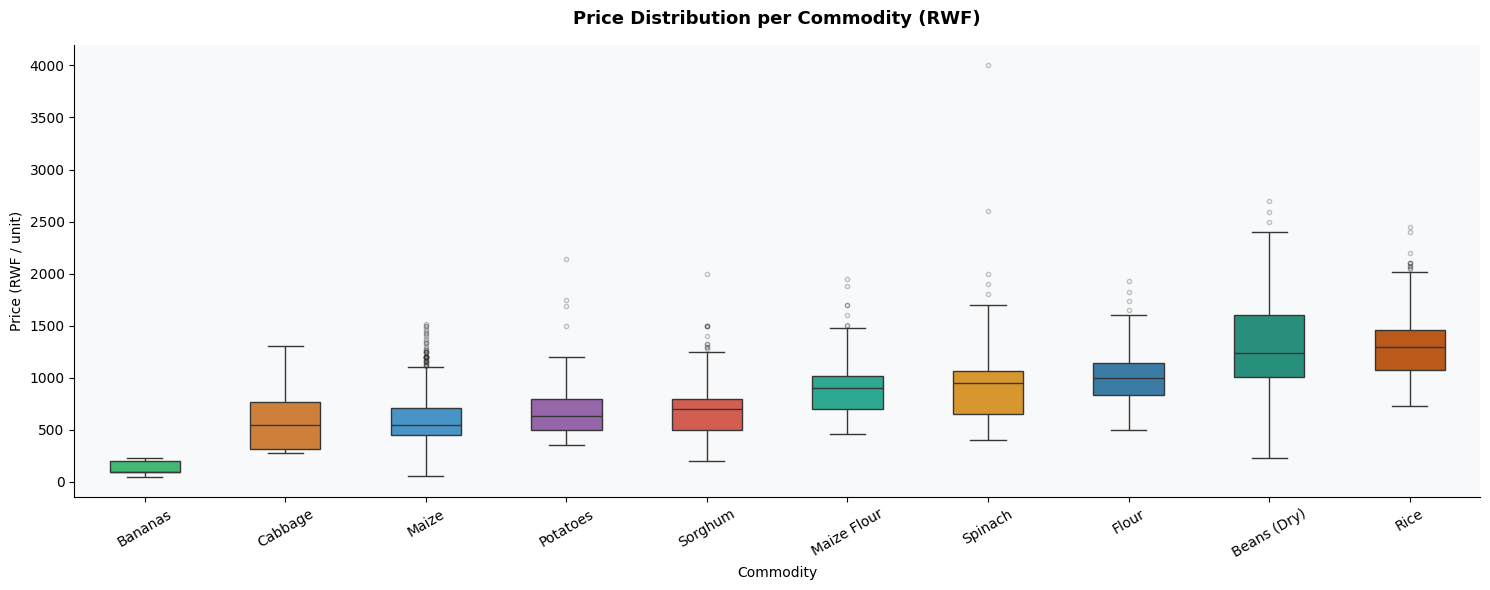

In [8]:
order = df_target.groupby('commodity_label')[PRICE_COL].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=df_target, x='commodity_label', y=PRICE_COL, order=order,
            palette=PALETTE[:len(order)], width=0.5,
            flierprops={'markersize': 3, 'alpha': 0.3}, ax=ax)
ax.set_title('Price Distribution per Commodity (RWF)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Commodity'); ax.set_ylabel('Price (RWF / unit)')
ax.tick_params(axis='x', rotation=30)
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz2_boxplot.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 3 - Price Trends Over Time
Monthly median price per commodity in RWF.

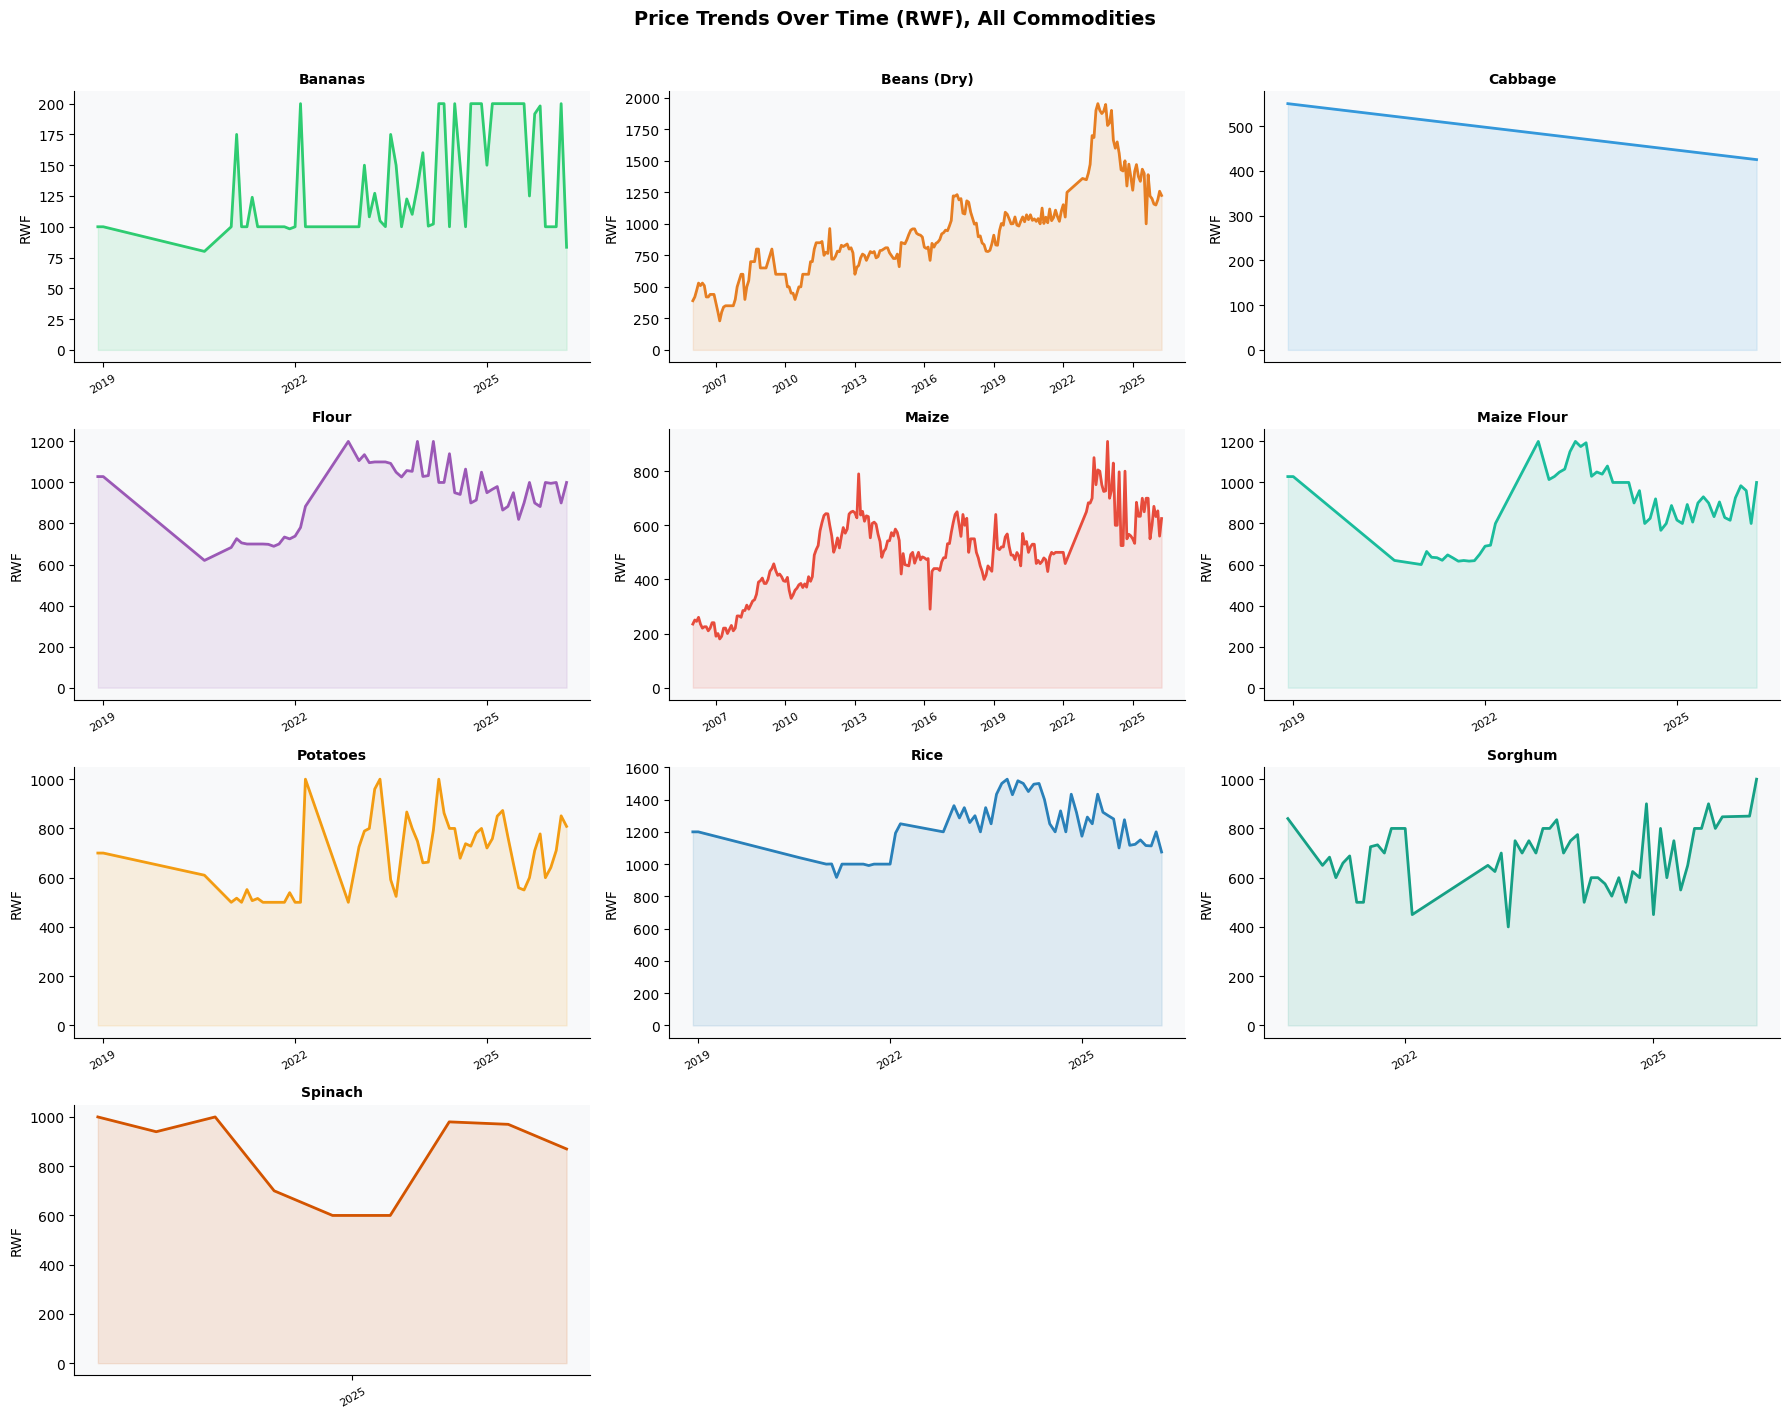

In [9]:
df_target['year_month'] = df_target[DATE_COL].dt.to_period('M')
monthly_avg = df_target.groupby(['year_month','commodity_label'])[PRICE_COL].median().reset_index()
monthly_avg['date'] = monthly_avg['year_month'].dt.to_timestamp()
commodities_list = sorted(monthly_avg['commodity_label'].unique())
ncols = 3; nrows = (len(commodities_list)+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3.5*nrows))
axes = axes.flatten()
for i, comm in enumerate(commodities_list):
    data = monthly_avg[monthly_avg['commodity_label']==comm]
    color = PALETTE[i % len(PALETTE)]
    axes[i].plot(data['date'], data[PRICE_COL], color=color, linewidth=2)
    axes[i].fill_between(data['date'], data[PRICE_COL], alpha=0.12, color=color)
    axes[i].set_title(comm, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('RWF')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(3))
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].set_facecolor('#F8F9FA')
for j in range(i+1, len(axes)): axes[j].set_visible(False)
fig.suptitle('Price Trends Over Time (RWF), All Commodities', fontsize=14, fontweight='bold', y=1.01)
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz3_trends.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 4 - Seasonal Price Index
Monthly price index relative to annual average, reveals lean and harvest seasons.

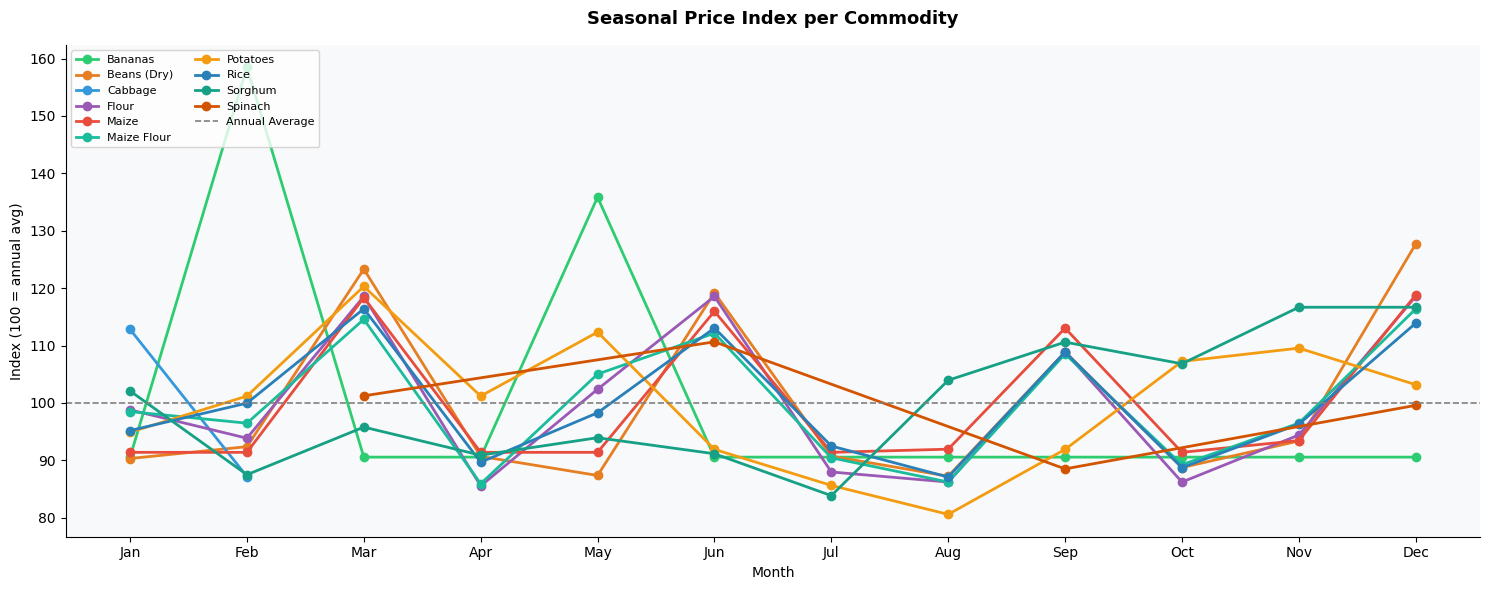

In [10]:
df_target['month'] = df_target[DATE_COL].dt.month
df_target['month_name'] = df_target[DATE_COL].dt.strftime('%b')
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal = df_target.groupby(['month','month_name','commodity_label'])[PRICE_COL].median().reset_index()
seasonal['month_name'] = pd.Categorical(seasonal['month_name'], categories=MONTH_ORDER, ordered=True)
seasonal = seasonal.sort_values(['commodity_label','month'])
fig, ax = plt.subplots(figsize=(15, 6))
for i, comm in enumerate(sorted(seasonal['commodity_label'].unique())):
    data = seasonal[seasonal['commodity_label']==comm].copy()
    mp = data[PRICE_COL].mean()
    if mp == 0: continue
    data['idx'] = (data[PRICE_COL] / mp) * 100
    ax.plot(data['month_name'], data['idx'], marker='o', linewidth=2,
            label=comm, color=PALETTE[i % len(PALETTE)])
ax.axhline(100, color='gray', linestyle='--', linewidth=1.2, label='Annual Average')
ax.set_title('Seasonal Price Index per Commodity', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month'); ax.set_ylabel('Index (100 = annual avg)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz4_seasonal.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 5 - Price Volatility
Coefficient of variation per commodity. Higher means harder to predict.

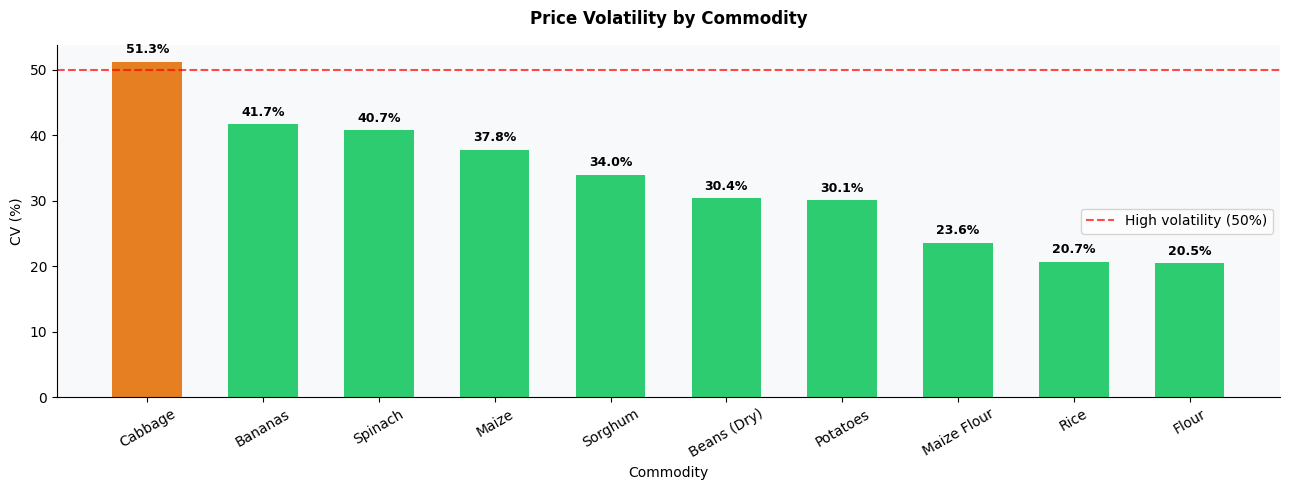

,commodity_label,mean_price,cv
2,Cabbage,606.63,51.25
0,Bananas,135.48,41.66
9,Spinach,949.13,40.74
4,Maize,594.30,37.80
8,Sorghum,679.58,34.01
1,Beans (Dry),1299.35,30.38
6,Potatoes,672.50,30.05
5,Maize Flour,886.69,23.56
7,Rice,1298.23,20.70
3,Flour,991.42,20.49


In [11]:
volatility = (df_target.groupby('commodity_label')[PRICE_COL]
              .agg(mean_price='mean', std_price='std')
              .assign(cv=lambda x: (x['std_price']/x['mean_price'])*100)
              .reset_index().sort_values('cv', ascending=False))
fig, ax = plt.subplots(figsize=(13, 5))
c_vol = [SP_ACCENT if v > 50 else SP_GREEN for v in volatility['cv']]
bars  = ax.bar(volatility['commodity_label'], volatility['cv'], color=c_vol, width=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9, fontweight='bold')
ax.axhline(50, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='High volatility (50%)')
ax.set_title('Price Volatility by Commodity', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Commodity'); ax.set_ylabel('CV (%)')
ax.tick_params(axis='x', rotation=30); ax.legend()
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz5_volatility.png', dpi=150, bbox_inches='tight'); plt.show()
display(volatility[['commodity_label','mean_price','cv']].round(2))

### Viz 6 - Price Correlation Across Commodities
Shows whether commodities respond to the same market pressures.

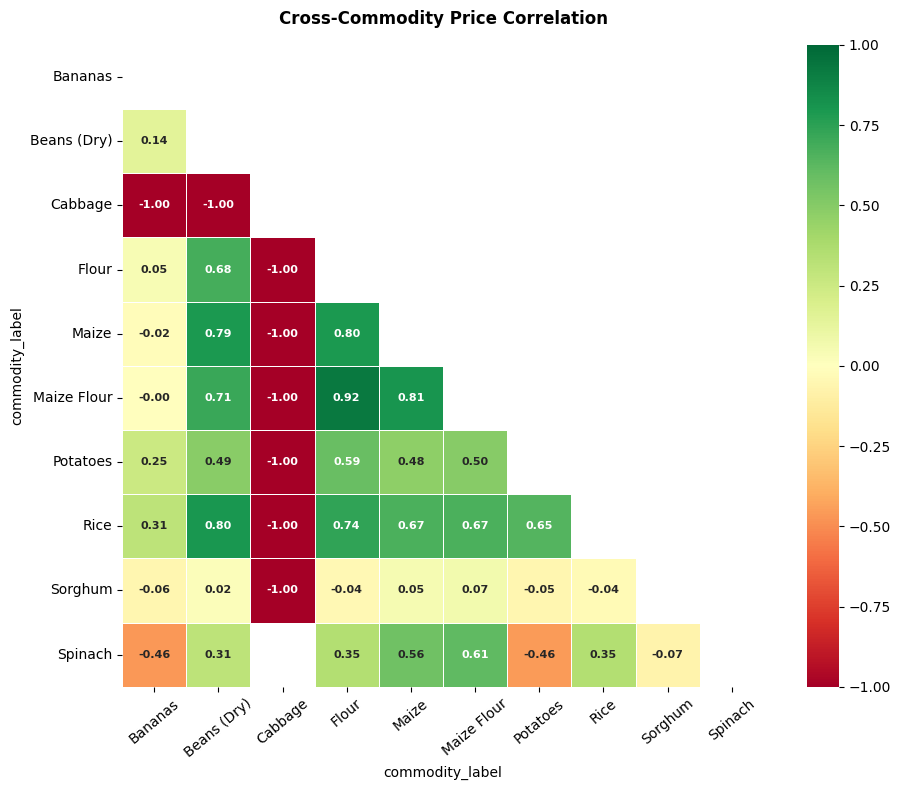

In [12]:
pivot = (df_target.groupby(['year_month','commodity_label'])[PRICE_COL]
         .median().unstack('commodity_label'))
pivot.index = pivot.index.to_timestamp()
corr = pivot.corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 8, 'weight': 'bold'}, ax=ax)
ax.set_title('Cross-Commodity Price Correlation', fontsize=12, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=40); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz6_correlation.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 7 - Price Comparison Across Kigali Markets
Shows predicted price differences across markets, validates recommendation feature.

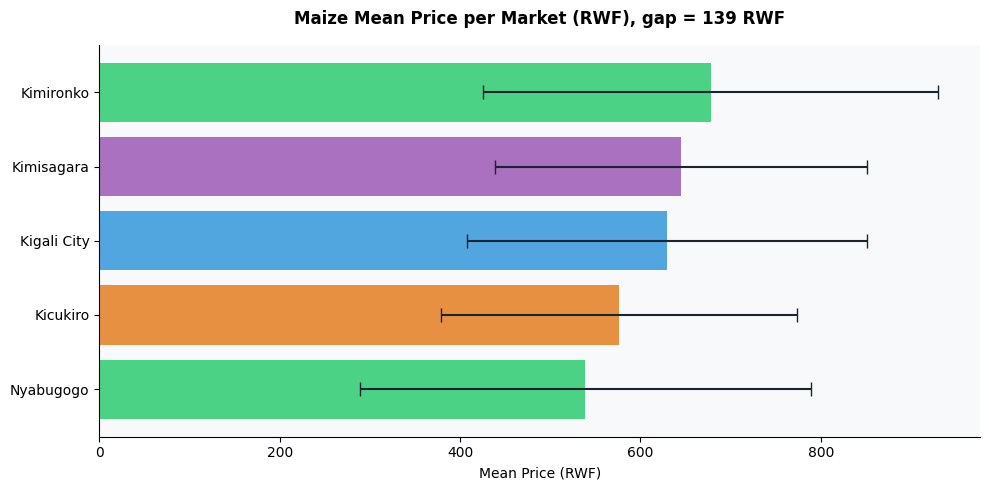

In [13]:
top_comm  = df_target['commodity_label'].value_counts().idxmax()
mkt_stats = (df_target[df_target['commodity_label']==top_comm]
             .groupby(MARKET_COL)[PRICE_COL]
             .agg(mean_price='mean', std_price='std', count='count').reset_index())
mkt_stats = mkt_stats[mkt_stats['count']>=10].sort_values('mean_price')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(mkt_stats[MARKET_COL], mkt_stats['mean_price'],
        xerr=mkt_stats['std_price'], color=PALETTE[:4], alpha=0.85,
        error_kw={'ecolor': SP_DARK, 'capsize': 5})
gap = mkt_stats['mean_price'].max() - mkt_stats['mean_price'].min()
ax.set_title(f'{top_comm} Mean Price per Market (RWF), gap = {gap:.0f} RWF',
             fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Mean Price (RWF)'); ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz7_market_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Phase 4 - Data Cleaning

Cleaning is kept separate from feature engineering. Missing prices are
filled using linear interpolation (average of surrounding values) rather
than dropping rows, which preserves time series continuity.

In [14]:
print('Rows before cleaning:', len(df_target))

# Remove exact duplicates
before = len(df_target)
df_clean = df_target.drop_duplicates(
    subset=[DATE_COL, MARKET_COL, COMM_COL, PRICE_COL]).copy()
print(f'Removed {before - len(df_clean)} duplicate rows')

# Linear interpolation for missing prices (preserves time series)
df_clean = df_clean.sort_values([COMM_COL, MARKET_COL, DATE_COL])
df_clean[PRICE_COL] = (df_clean.groupby([COMM_COL, MARKET_COL])[PRICE_COL]
                       .transform(lambda x: x.interpolate(method='linear')))

# Cap outliers at 3 standard deviations per commodity
def cap_outliers(group):
    mean, std = group[PRICE_COL].mean(), group[PRICE_COL].std()
    return group[(group[PRICE_COL] >= mean - 3*std) & (group[PRICE_COL] <= mean + 3*std)]

before = len(df_clean)
df_clean = df_clean.groupby('commodity_label', group_keys=False).apply(cap_outliers)
print(f'Removed {before - len(df_clean)} outlier rows')

# Null check
key_cols = [DATE_COL, MARKET_COL, COMM_COL, PRICE_COL, 'commodity_label']
null_check = df_clean[key_cols].isnull().sum()
assert null_check.sum() == 0, 'Nulls remain, check before continuing'

print(f'Rows after cleaning: {len(df_clean):,}')

Rows before cleaning: 9582
Removed 1120 duplicate rows
Removed 45 outlier rows
Rows after cleaning: 8,417


### Viz 8 - Class Balance After Cleaning
Confirms no commodity is too underrepresented for the model to learn its pattern.

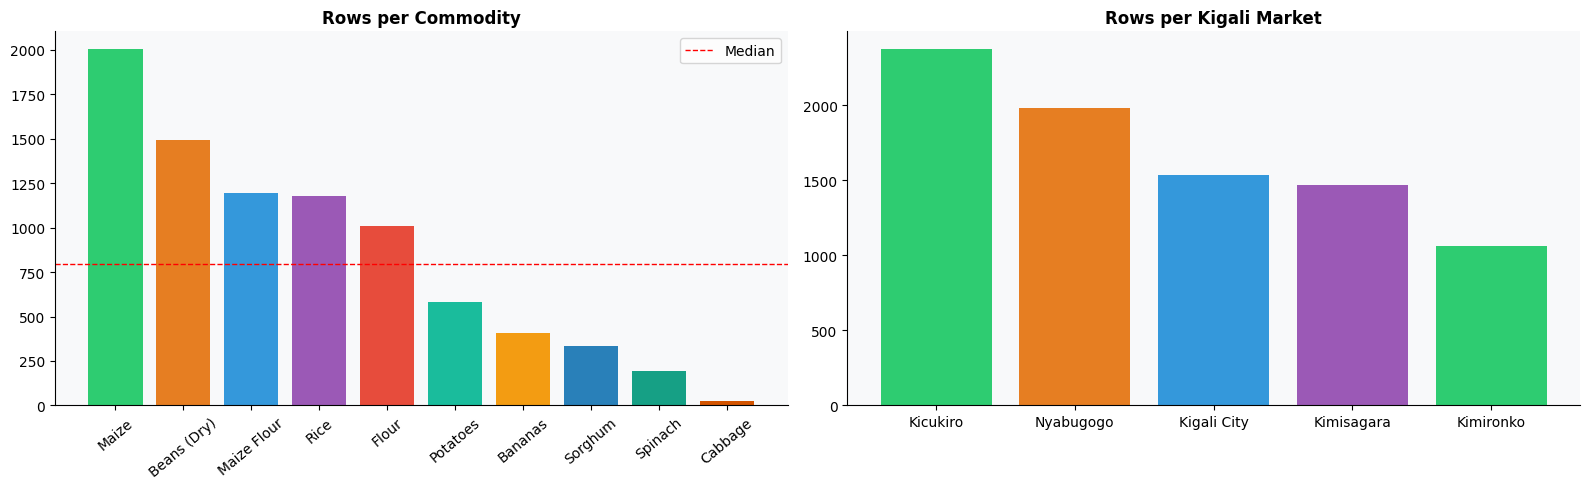

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
comm_counts = df_clean['commodity_label'].value_counts()
axes[0].bar(comm_counts.index, comm_counts.values, color=PALETTE[:len(comm_counts)])
axes[0].set_title('Rows per Commodity', fontweight='bold')
axes[0].tick_params(axis='x', rotation=40)
axes[0].axhline(comm_counts.median(), color='red', linestyle='--', lw=1, label='Median')
axes[0].legend(); axes[0].set_facecolor('#F8F9FA')
mkt_counts = df_clean[MARKET_COL].value_counts()
axes[1].bar(mkt_counts.index, mkt_counts.values, color=PALETTE[:4])
axes[1].set_title('Rows per Kigali Market', fontweight='bold')
axes[1].set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz8_balance.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Phase 5 - Feature Engineering and Labeling

All features are numeric. Each block states what it captures and why.

In [16]:
df = df_clean.copy()
df = df.sort_values([COMM_COL, MARKET_COL, DATE_COL]).reset_index(drop=True)

# Temporal features
df['year']        = df[DATE_COL].dt.year
df['month']       = df[DATE_COL].dt.month
df['quarter']     = df[DATE_COL].dt.quarter
df['day_of_year'] = df[DATE_COL].dt.dayofyear

# Cyclical encoding - fixes discontinuity between December and January
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

print('Temporal features created')
df[['month','month_sin','month_cos']].drop_duplicates().sort_values('month')

Temporal features created


,month,month_sin,month_cos
1,1,5.000000e-01,8.660254e-01
4,2,8.660254e-01,5.000000e-01
6,3,1.000000e+00,6.123234e-17
9,4,8.660254e-01,-5.000000e-01
13,5,5.000000e-01,-8.660254e-01
17,6,1.224647e-16,-1.000000e+00
22,7,-5.000000e-01,-8.660254e-01
0,8,-8.660254e-01,-5.000000e-01
29,9,-1.000000e+00,-1.836970e-16
33,10,-8.660254e-01,5.000000e-01


In [17]:
grp = df.groupby([COMM_COL, MARKET_COL])[PRICE_COL]

# Lag features - recent price history is the strongest predictor
for lag in [1, 2, 3, 6]:
    df[f'price_lag_{lag}'] = grp.shift(lag)

# Rolling stats - smooths noise, captures trend level and volatility
for w in [3, 6, 12]:
    df[f'rolling_mean_{w}'] = grp.transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    df[f'rolling_std_{w}'] = grp.transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).std().fillna(0))

# Price momentum
df['price_pct_change_1m'] = grp.pct_change(1).replace([np.inf, -np.inf], np.nan)
df['price_pct_change_3m'] = grp.pct_change(3).replace([np.inf, -np.inf], np.nan)

print('Lag, rolling, and momentum features created')

Lag, rolling, and momentum features created


In [18]:
# Label encoding - converts text labels to integers
le_comm   = LabelEncoder()
le_market = LabelEncoder()
df['commodity_enc'] = le_comm.fit_transform(df['commodity_label'])
df['market_enc']    = le_market.fit_transform(df[MARKET_COL].astype(str))

print('Commodity classes:', dict(zip(le_comm.classes_, range(len(le_comm.classes_)))))
print('Market classes:', dict(zip(le_market.classes_, range(len(le_market.classes_)))))

# Save encoders for API use
joblib.dump(le_comm,   'le_commodity.pkl')
joblib.dump(le_market, 'le_market.pkl')
print('Encoders saved')

Commodity classes: {'Bananas': 0, 'Beans (Dry)': 1, 'Cabbage': 2, 'Flour': 3, 'Maize': 4, 'Maize Flour': 5, 'Potatoes': 6, 'Rice': 7, 'Sorghum': 8, 'Spinach': 9}
Market classes: {'Kicukiro': 0, 'Kigali City': 1, 'Kimironko': 2, 'Kimisagara': 3, 'Nyabugogo': 4}
Encoders saved


In [19]:
FEATURE_COLS = [
    'year', 'month_sin', 'month_cos', 'quarter', 'day_of_year',
    'price_lag_1', 'price_lag_2', 'price_lag_3', 'price_lag_6',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12',
    'rolling_std_3', 'rolling_std_6',
    'price_pct_change_1m', 'price_pct_change_3m',
    'commodity_enc', 'market_enc'
]
TARGET_COL = PRICE_COL

df_ml = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
print(f'ML dataset: {df_ml.shape[0]:,} rows x {len(FEATURE_COLS)} features')
print(f'Rows dropped from lag NaNs: {len(df) - len(df_ml):,}')

ML dataset: 7,975 rows x 18 features
Rows dropped from lag NaNs: 442


### Viz 9 - Feature Correlation with Target Price
Confirms which features the model is most likely to rely on.

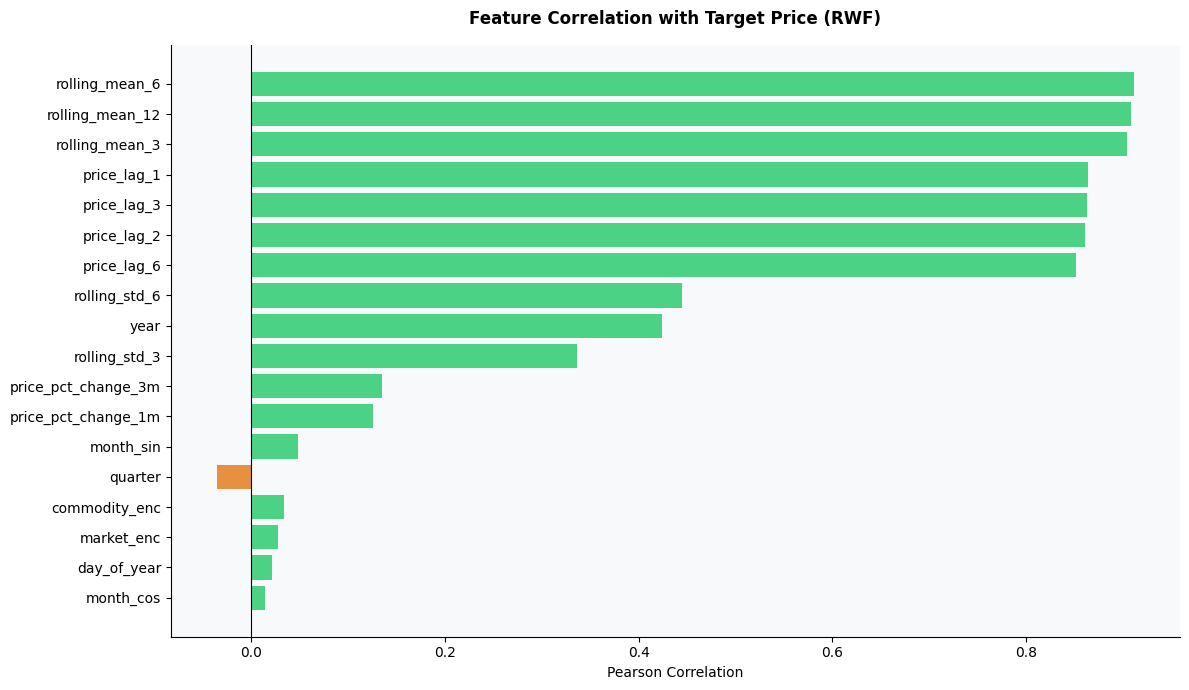

Top 5 features: ['rolling_mean_6', 'rolling_mean_12', 'rolling_mean_3', 'price_lag_1', 'price_lag_3']


In [20]:
corr_target = (df_ml[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL]
               .drop(TARGET_COL).sort_values(key=abs, ascending=False))
fig, ax = plt.subplots(figsize=(12, 7))
colors_f = [SP_GREEN if v > 0 else SP_ACCENT for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1],
        color=colors_f[::-1], alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Target Price (RWF)', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Pearson Correlation'); ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz9_feature_corr.png', dpi=150, bbox_inches='tight'); plt.show()
print('Top 5 features:', corr_target.head().index.tolist())

---
## Phase 6 - Data Normalization

Features span very different scales. Normalization ensures no feature
dominates the model due to magnitude alone. Scaler is fit on training
data only during each rolling window fold.

In [21]:
X_all = df_ml[FEATURE_COLS].values
print('Feature ranges before scaling:')
for i, col in enumerate(FEATURE_COLS):
    print(f'  {col:25s} min={X_all[:,i].min():>10.1f}  max={X_all[:,i].max():>10.1f}')

Feature ranges before scaling:
  year                      min=    2006.0  max=    2026.0
  month_sin                 min=      -1.0  max=       1.0
  month_cos                 min=      -1.0  max=       1.0
  quarter                   min=       1.0  max=       4.0
  day_of_year               min=      15.0  max=     350.0
  price_lag_1               min=      50.0  max=    2400.0
  price_lag_2               min=      50.0  max=    2400.0
  price_lag_3               min=      50.0  max=    2400.0
  price_lag_6               min=      50.0  max=    2400.0
  rolling_mean_3            min=      63.4  max=    2054.2
  rolling_mean_6            min=      66.2  max=    2039.9
  rolling_mean_12           min=      74.7  max=    1957.9
  rolling_std_3             min=       0.0  max=     702.4
  rolling_std_6             min=       0.0  max=     568.2
  price_pct_change_1m       min=      -0.8  max=       3.0
  price_pct_change_3m       min=      -0.8  max=       3.0
  commodity_enc          

### Viz 10 - Feature Value Ranges
Log scale shows why normalization is needed.

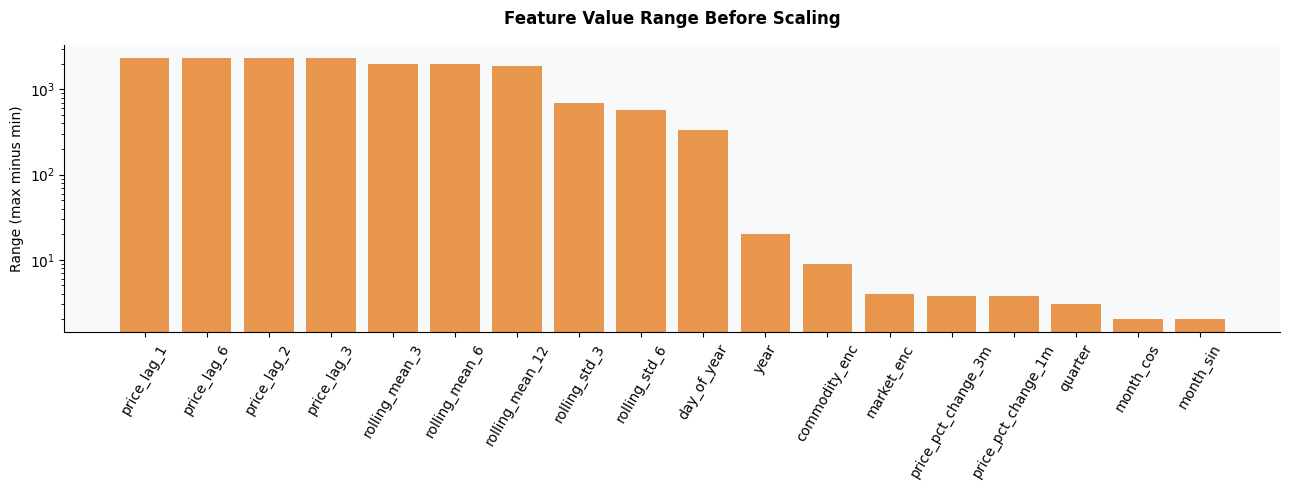

In [22]:
fig, ax = plt.subplots(figsize=(13, 5))
ranges = [X_all[:,i].max() - X_all[:,i].min() for i in range(len(FEATURE_COLS))]
order_idx = np.argsort(ranges)[::-1]
ax.bar([FEATURE_COLS[i] for i in order_idx],
       [ranges[i] for i in order_idx], color=SP_ACCENT, alpha=0.8)
ax.set_title('Feature Value Range Before Scaling', fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel('Range (max minus min)'); ax.tick_params(axis='x', rotation=60)
ax.set_yscale('log')
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz10_scale.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Phase 7 - Rolling Window Validation

Instead of a single train/test split, a rolling window approach is used.
The model trains on 3 years of data and predicts the 4th year. The window
then shifts forward one year and repeats. This directly mimics how the
model will be used in production and gives a more honest accuracy estimate.

Each fold:
- Train: years N, N+1, N+2
- Test : year N+3

In [23]:
df_ml = df_ml.sort_values(DATE_COL).reset_index(drop=True)
df_ml['year'] = df_ml[DATE_COL].dt.year

years     = sorted(df_ml['year'].unique())
min_year  = min(years)
max_year  = max(years)

folds = []
for start in range(min_year, max_year - 2):
    train_years = [start, start+1, start+2]
    test_year   = start + 3
    if test_year > max_year:
        break
    train_mask = df_ml['year'].isin(train_years)
    test_mask  = df_ml['year'] == test_year
    if train_mask.sum() < 50 or test_mask.sum() < 10:
        continue
    folds.append({
        'train_years': train_years,
        'test_year'  : test_year,
        'train_idx'  : df_ml[train_mask].index.tolist(),
        'test_idx'   : df_ml[test_mask].index.tolist()
    })

print(f'Rolling window folds: {len(folds)}')
for f in folds:
    print(f'  Train {f["train_years"]} -> Test {f["test_year"]} | '
          f'train={len(f["train_idx"]):,} test={len(f["test_idx"]):,}')

Rolling window folds: 18
  Train [2006, 2007, 2008] -> Test 2009 | train=158 test=59
  Train [2007, 2008, 2009] -> Test 2010 | train=177 test=58
  Train [2008, 2009, 2010] -> Test 2011 | train=175 test=57
  Train [2009, 2010, 2011] -> Test 2012 | train=174 test=59
  Train [2010, 2011, 2012] -> Test 2013 | train=174 test=58
  Train [2011, 2012, 2013] -> Test 2014 | train=174 test=58
  Train [2012, 2013, 2014] -> Test 2015 | train=175 test=115
  Train [2013, 2014, 2015] -> Test 2016 | train=231 test=143
  Train [2014, 2015, 2016] -> Test 2017 | train=316 test=151
  Train [2015, 2016, 2017] -> Test 2018 | train=409 test=156
  Train [2016, 2017, 2018] -> Test 2019 | train=450 test=153
  Train [2017, 2018, 2019] -> Test 2020 | train=460 test=145
  Train [2018, 2019, 2020] -> Test 2021 | train=454 test=1,624
  Train [2019, 2020, 2021] -> Test 2022 | train=1,922 test=212
  Train [2020, 2021, 2022] -> Test 2023 | train=1,981 test=1,084
  Train [2021, 2022, 2023] -> Test 2024 | train=2,920 test

### Viz 11 - Rolling Window Split Visualization
Shows how the training window shifts forward each fold.

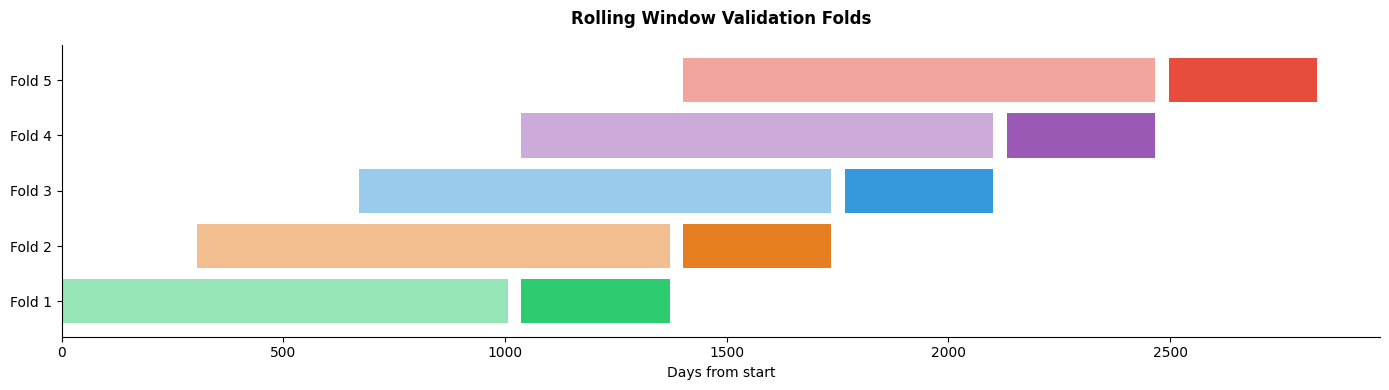

In [24]:
fig, ax = plt.subplots(figsize=(14, 4))
colors_fold = [SP_GREEN, SP_ACCENT, SP_BLUE, '#9B59B6', '#E74C3C']
for i, fold in enumerate(folds[:5]):
    train_data = df_ml[df_ml.index.isin(fold['train_idx'])]
    test_data  = df_ml[df_ml.index.isin(fold['test_idx'])]
    c = colors_fold[i % len(colors_fold)]
    ax.barh(i, (train_data[DATE_COL].max() - train_data[DATE_COL].min()).days,
            left=train_data[DATE_COL].min().toordinal() - df_ml[DATE_COL].min().toordinal(),
            color=c, alpha=0.5, label=f'Train fold {i+1}' if i==0 else '')
    ax.barh(i, (test_data[DATE_COL].max() - test_data[DATE_COL].min()).days,
            left=test_data[DATE_COL].min().toordinal() - df_ml[DATE_COL].min().toordinal(),
            color=c, alpha=1.0, label=f'Test fold {i+1}' if i==0 else '')
ax.set_yticks(range(min(5, len(folds))))
ax.set_yticklabels([f'Fold {i+1}' for i in range(min(5, len(folds)))])
ax.set_title('Rolling Window Validation Folds', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Days from start')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz11_rolling.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Phase 8 - Model Training and Hyperparameter Tuning

Five models are trained and compared:
- Linear Regression (baseline)
- Ridge Regression (handles multicollinearity)
- Random Forest
- XGBoost
- LightGBM

Each model is trained and evaluated across all rolling window folds.
Hyperparameter tuning is applied to XGBoost and LightGBM using
RandomizedSearchCV within the training fold only.

In [25]:
def evaluate(name, y_true, y_pred, fold=None):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    # Directional accuracy
    if len(y_true) > 1:
        dir_acc = np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))) * 100
    else:
        dir_acc = 0.0
    label = f'{name} (fold {fold})' if fold else name
    print(f'  {label}: MAE={mae:.1f} RMSE={rmse:.1f} R2={r2:.4f} MAPE={mape:.2f}% DirAcc={dir_acc:.1f}%')
    return {'Model': name, 'Fold': fold, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
            'R2': round(r2,4), 'MAPE (%)': round(mape,2), 'DirAcc (%)': round(dir_acc,2)}

all_results = []
print('Evaluation helper ready')

Evaluation helper ready


### Models 1 and 2 - Linear Regression and Ridge Regression

In [26]:
print('Training Linear Regression and Ridge...')
for fold_idx, fold in enumerate(folds):
    X_tr = df_ml.loc[fold['train_idx'], FEATURE_COLS].values
    y_tr = df_ml.loc[fold['train_idx'], TARGET_COL].values
    X_te = df_ml.loc[fold['test_idx'],  FEATURE_COLS].values
    y_te = df_ml.loc[fold['test_idx'],  TARGET_COL].values

    scaler = MinMaxScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_tr_sc, y_tr)
    y_pred = np.clip(lr.predict(X_te_sc), 0, None)
    all_results.append(evaluate('Linear Regression', y_te, y_pred, fold_idx+1))

    # Ridge Regression
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_tr_sc, y_tr)
    y_pred = np.clip(ridge.predict(X_te_sc), 0, None)
    all_results.append(evaluate('Ridge Regression', y_te, y_pred, fold_idx+1))

print('Done')

Training Linear Regression and Ridge...
  Linear Regression (fold 1): MAE=20.6 RMSE=28.5 R2=0.9425 MAPE=4.21% DirAcc=96.6%
  Ridge Regression (fold 1): MAE=32.1 RMSE=41.2 R2=0.8797 MAPE=7.01% DirAcc=94.8%
  Linear Regression (fold 2): MAE=26.4 RMSE=36.1 R2=0.9268 MAPE=10.81% DirAcc=93.0%
  Ridge Regression (fold 2): MAE=47.2 RMSE=61.1 R2=0.7905 MAPE=19.78% DirAcc=93.0%
  Linear Regression (fold 3): MAE=23.5 RMSE=31.6 R2=0.9666 MAPE=4.22% DirAcc=92.9%
  Ridge Regression (fold 3): MAE=52.9 RMSE=65.2 R2=0.8584 MAPE=9.14% DirAcc=91.1%
  Linear Regression (fold 4): MAE=35.9 RMSE=45.4 R2=0.9209 MAPE=5.46% DirAcc=96.6%
  Ridge Regression (fold 4): MAE=53.7 RMSE=65.0 R2=0.8382 MAPE=8.98% DirAcc=94.8%
  Linear Regression (fold 5): MAE=31.8 RMSE=54.2 R2=0.9083 MAPE=5.39% DirAcc=87.7%
  Ridge Regression (fold 5): MAE=51.5 RMSE=70.5 R2=0.8445 MAPE=9.75% DirAcc=89.5%
  Linear Regression (fold 6): MAE=20.0 RMSE=23.6 R2=0.9787 MAPE=3.63% DirAcc=96.5%
  Ridge Regression (fold 6): MAE=32.6 RMSE=42.9 R2

### Model 3 - Random Forest

In [27]:
print('Training Random Forest...')
for fold_idx, fold in enumerate(folds):
    X_tr = df_ml.loc[fold['train_idx'], FEATURE_COLS].values
    y_tr = df_ml.loc[fold['train_idx'], TARGET_COL].values
    X_te = df_ml.loc[fold['test_idx'],  FEATURE_COLS].values
    y_te = df_ml.loc[fold['test_idx'],  TARGET_COL].values

    rf = RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_split=5,
        min_samples_leaf=2, max_features='sqrt', n_jobs=-1, random_state=42
    )
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    all_results.append(evaluate('Random Forest', y_te, y_pred, fold_idx+1))

print('Done')

Training Random Forest...
  Random Forest (fold 1): MAE=32.4 RMSE=41.5 R2=0.8779 MAPE=7.06% DirAcc=93.1%
  Random Forest (fold 2): MAE=43.9 RMSE=59.2 R2=0.8035 MAPE=18.66% DirAcc=94.7%
  Random Forest (fold 3): MAE=66.9 RMSE=89.5 R2=0.7330 MAPE=11.11% DirAcc=89.3%
  Random Forest (fold 4): MAE=73.0 RMSE=94.6 R2=0.6571 MAPE=11.73% DirAcc=82.8%
  Random Forest (fold 5): MAE=47.6 RMSE=66.5 R2=0.8620 MAPE=8.85% DirAcc=87.7%
  Random Forest (fold 6): MAE=38.1 RMSE=49.9 R2=0.9052 MAPE=6.82% DirAcc=91.2%
  Random Forest (fold 7): MAE=94.8 RMSE=120.8 R2=0.6671 MAPE=15.50% DirAcc=86.8%
  Random Forest (fold 8): MAE=36.9 RMSE=54.6 R2=0.9346 MAPE=6.56% DirAcc=94.4%
  Random Forest (fold 9): MAE=103.5 RMSE=140.4 R2=0.7391 MAPE=12.87% DirAcc=88.7%
  Random Forest (fold 10): MAE=54.6 RMSE=74.2 R2=0.8990 MAPE=9.68% DirAcc=96.1%
  Random Forest (fold 11): MAE=35.9 RMSE=54.6 R2=0.9500 MAPE=5.18% DirAcc=93.4%
  Random Forest (fold 12): MAE=37.1 RMSE=47.9 R2=0.9686 MAPE=6.19% DirAcc=95.8%
  Random Forest

### Model 4 - XGBoost with Hyperparameter Tuning

In [28]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

print('Training XGBoost with hyperparameter search...')
xgb_param_grid = {
    'n_estimators'    : [200, 300, 500],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'max_depth'       : [4, 6, 8],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}

best_xgb = None
best_xgb_score = np.inf

for fold_idx, fold in enumerate(folds):
    X_tr = df_ml.loc[fold['train_idx'], FEATURE_COLS].values
    y_tr = df_ml.loc[fold['train_idx'], TARGET_COL].values
    X_te = df_ml.loc[fold['test_idx'],  FEATURE_COLS].values
    y_te = df_ml.loc[fold['test_idx'],  TARGET_COL].values

    xgb_search = RandomizedSearchCV(
        XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        xgb_param_grid, n_iter=10, cv=3,
        scoring='neg_mean_absolute_error',
        random_state=42, n_jobs=-1, verbose=0
    )
    xgb_search.fit(X_tr, y_tr)
    y_pred = xgb_search.best_estimator_.predict(X_te)
    res = evaluate('XGBoost', y_te, y_pred, fold_idx+1)
    all_results.append(res)

    if res['MAPE (%)'] < best_xgb_score:
        best_xgb_score = res['MAPE (%)']
        best_xgb = xgb_search.best_estimator_

joblib.dump(best_xgb, 'model_xgb_tuned.pkl')
print(f'Best XGBoost params: {xgb_search.best_params_}')
print('Saved: model_xgb_tuned.pkl')

Training XGBoost with hyperparameter search...
  XGBoost (fold 1): MAE=36.5 RMSE=44.0 R2=0.8629 MAPE=8.34% DirAcc=87.9%
  XGBoost (fold 2): MAE=24.8 RMSE=34.5 R2=0.9330 MAPE=10.26% DirAcc=94.7%
  XGBoost (fold 3): MAE=62.7 RMSE=88.1 R2=0.7412 MAPE=10.06% DirAcc=91.1%
  XGBoost (fold 4): MAE=59.3 RMSE=85.1 R2=0.7227 MAPE=8.99% DirAcc=84.5%
  XGBoost (fold 5): MAE=35.3 RMSE=54.5 R2=0.9072 MAPE=6.55% DirAcc=96.5%
  XGBoost (fold 6): MAE=20.0 RMSE=29.5 R2=0.9668 MAPE=3.73% DirAcc=93.0%
  XGBoost (fold 7): MAE=77.2 RMSE=103.9 R2=0.7537 MAPE=12.78% DirAcc=87.7%
  XGBoost (fold 8): MAE=34.3 RMSE=53.2 R2=0.9377 MAPE=6.08% DirAcc=96.5%
  XGBoost (fold 9): MAE=88.0 RMSE=122.5 R2=0.8013 MAPE=10.89% DirAcc=92.0%
  XGBoost (fold 10): MAE=33.3 RMSE=47.1 R2=0.9593 MAPE=5.54% DirAcc=96.1%
  XGBoost (fold 11): MAE=25.3 RMSE=40.2 R2=0.9729 MAPE=3.93% DirAcc=95.4%
  XGBoost (fold 12): MAE=26.7 RMSE=34.0 R2=0.9842 MAPE=4.47% DirAcc=96.5%
  XGBoost (fold 13): MAE=76.2 RMSE=136.6 R2=0.7791 MAPE=43.58% DirAc

### Model 5 - LightGBM with Hyperparameter Tuning

In [29]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

print('Training LightGBM...')
lgbm_params = {
    'n_estimators': 300,
    'learning_rate': 0.05,
    'num_leaves': 63,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

best_lgbm = None
best_lgbm_score = np.inf

for fold_idx, fold in enumerate(folds):
    X_tr = df_ml.loc[fold['train_idx'], FEATURE_COLS].values
    y_tr = df_ml.loc[fold['train_idx'], TARGET_COL].values
    X_te = df_ml.loc[fold['test_idx'], FEATURE_COLS].values
    y_te = df_ml.loc[fold['test_idx'], TARGET_COL].values

    lgbm_model = lgb.LGBMRegressor(**lgbm_params)
    lgbm_model.fit(X_tr, y_tr)
    y_pred = lgbm_model.predict(X_te)
    res = evaluate('LightGBM', y_te, y_pred, fold_idx+1)
    all_results.append(res)

    if res['MAPE (%)'] < best_lgbm_score:
        best_lgbm_score = res['MAPE (%)']
        best_lgbm = lgbm_model

joblib.dump(best_lgbm, 'model_lgbm_tuned.pkl')
print(f'LightGBM params used: {lgbm_params}')
print('Saved: model_lgbm_tuned.pkl')

Training LightGBM...
  LightGBM (fold 1): MAE=69.2 RMSE=88.0 R2=0.4517 MAPE=14.42% DirAcc=75.9%
  LightGBM (fold 2): MAE=27.3 RMSE=42.6 R2=0.8982 MAPE=9.29% DirAcc=94.7%
  LightGBM (fold 3): MAE=62.4 RMSE=88.8 R2=0.7375 MAPE=11.17% DirAcc=82.1%
  LightGBM (fold 4): MAE=53.3 RMSE=69.7 R2=0.8136 MAPE=8.38% DirAcc=91.4%
  LightGBM (fold 5): MAE=32.2 RMSE=50.1 R2=0.9217 MAPE=5.95% DirAcc=93.0%
  LightGBM (fold 6): MAE=30.5 RMSE=40.1 R2=0.9386 MAPE=6.08% DirAcc=96.5%
  LightGBM (fold 7): MAE=93.8 RMSE=117.8 R2=0.6837 MAPE=15.65% DirAcc=84.2%
  LightGBM (fold 8): MAE=32.4 RMSE=46.9 R2=0.9516 MAPE=5.44% DirAcc=95.8%
  LightGBM (fold 9): MAE=91.7 RMSE=128.8 R2=0.7802 MAPE=11.46% DirAcc=92.7%
  LightGBM (fold 10): MAE=32.8 RMSE=46.8 R2=0.9598 MAPE=5.84% DirAcc=96.1%
  LightGBM (fold 11): MAE=25.4 RMSE=42.9 R2=0.9692 MAPE=3.81% DirAcc=94.1%
  LightGBM (fold 12): MAE=22.2 RMSE=28.7 R2=0.9887 MAPE=3.61% DirAcc=97.9%
  LightGBM (fold 13): MAE=78.2 RMSE=134.7 R2=0.7851 MAPE=41.60% DirAcc=87.0%
  Lig

---
## Phase 9 - Evaluation and Model Comparison

Results are averaged across all rolling window folds for each model.
The best model is selected based on MAPE (primary metric) and saved
for use in the FastAPI backend.

In [30]:
results_df = pd.DataFrame(all_results)

# Average metrics across folds per model
summary = (results_df.groupby('Model')
           .agg({'MAE': 'mean', 'RMSE': 'mean', 'R2': 'mean',
                 'MAPE (%)': 'mean', 'DirAcc (%)': 'mean'})
           .round(3).sort_values('MAPE (%)'))

print('=' * 75)
print('   SOKOPRICE - MODEL COMPARISON (Average across rolling window folds)')
print('=' * 75)
print(summary.to_string())
print('=' * 75)

best_model_name = summary.index[0]
best = summary.iloc[0]
print(f'\nBest model: {best_model_name}')
print(f'  MAPE    : {best["MAPE (%)"]:.2f}% (primary metric)')
print(f'  R2      : {best["R2"]:.4f}')
print(f'  MAE     : {best["MAE"]:.2f} RWF')
print(f'  DirAcc  : {best["DirAcc (%)"]:.1f}%')

   SOKOPRICE - MODEL COMPARISON (Average across rolling window folds)
                      MAE    RMSE     R2  MAPE (%)  DirAcc (%)
Model                                                         
XGBoost            45.898  69.843  0.886     8.751      92.814
Linear Regression  48.174  70.531  0.921     8.780      93.263
LightGBM           48.657  72.670  0.863     9.130      91.997
Ridge Regression   55.941  77.586  0.894    10.427      92.837
Random Forest      62.980  89.980  0.839    11.686      91.168

Best model: XGBoost
  MAPE    : 8.75% (primary metric)
  R2      : 0.8860
  MAE     : 45.90 RWF
  DirAcc  : 92.8%


### Viz 12 - MAPE Comparison Across Models
Lower MAPE means the model makes smaller percentage errors on average.

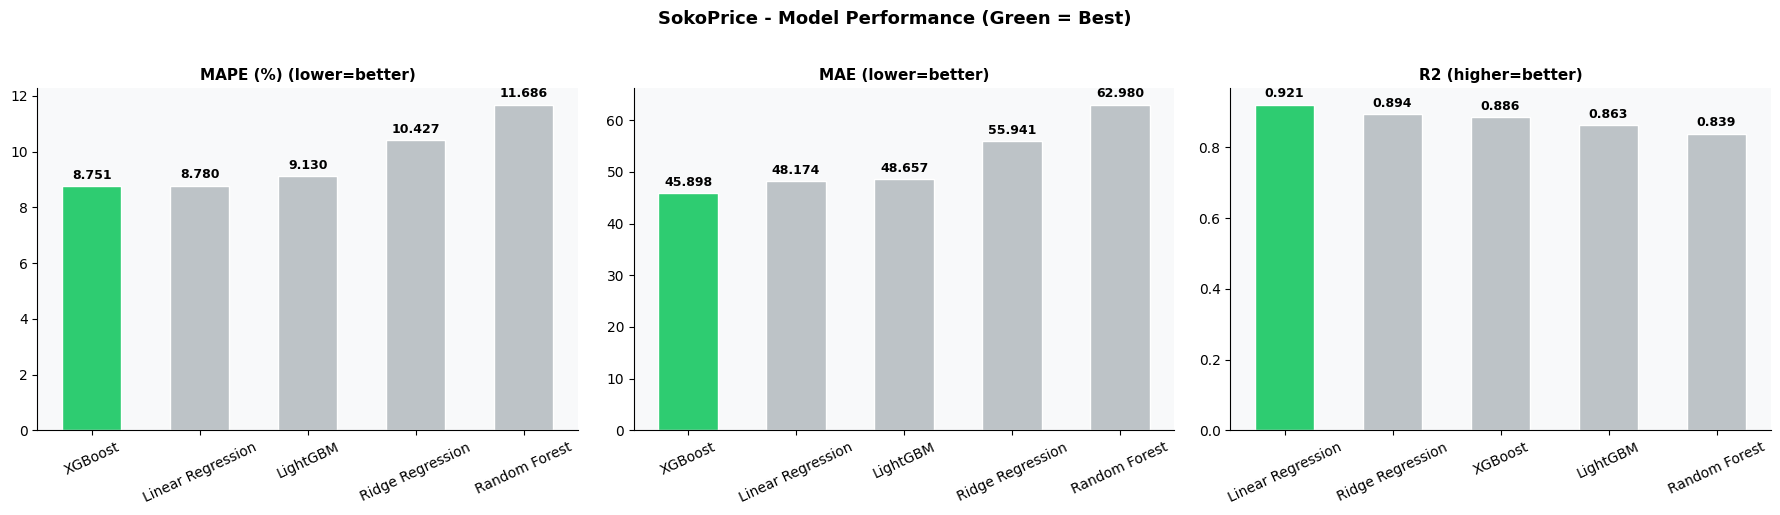

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, metric in enumerate(['MAPE (%)', 'MAE', 'R2']):
    df_s = summary.sort_values(metric, ascending=(metric != 'R2'))
    c_m  = [SP_GREEN if j==0 else '#BDC3C7' for j in range(len(df_s))]
    bars = axes[i].bar(df_s.index, df_s[metric], color=c_m, edgecolor='white', width=0.55)
    axes[i].bar_label(bars, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')
    direction = 'lower=better' if metric != 'R2' else 'higher=better'
    axes[i].set_title(f'{metric} ({direction})', fontweight='bold', fontsize=11)
    axes[i].tick_params(axis='x', rotation=25); axes[i].set_facecolor('#F8F9FA')
fig.suptitle('SokoPrice - Model Performance (Green = Best)', fontsize=13, fontweight='bold', y=1.02)
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz12_model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 13 - Directional Accuracy
Percentage of correct up/down price movement predictions per model.

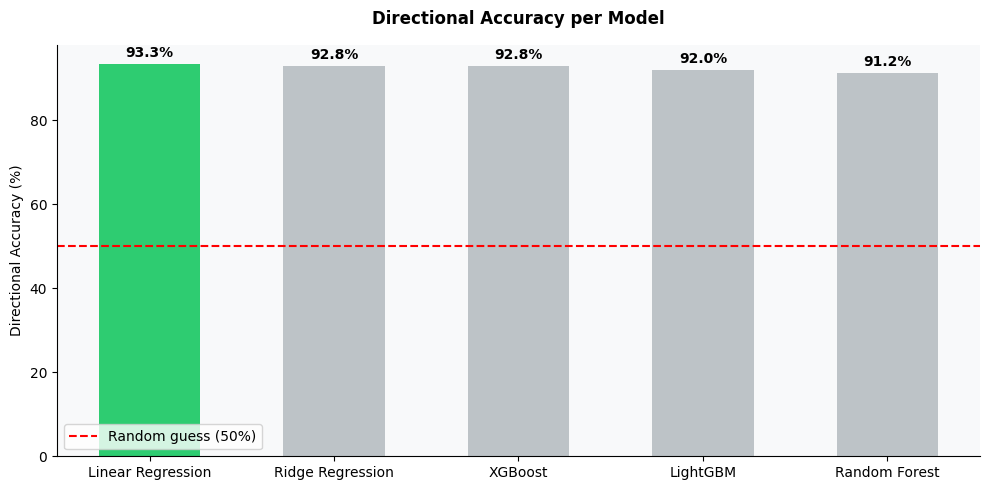

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
df_dir = summary.sort_values('DirAcc (%)', ascending=False)
c_dir  = [SP_GREEN if j==0 else '#BDC3C7' for j in range(len(df_dir))]
bars   = ax.bar(df_dir.index, df_dir['DirAcc (%)'], color=c_dir, width=0.55)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10, fontweight='bold')
ax.axhline(50, color='red', linestyle='--', lw=1.5, label='Random guess (50%)')
ax.set_title('Directional Accuracy per Model', fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel('Directional Accuracy (%)'); ax.legend()
ax.set_facecolor('#F8F9FA'); fig.patch.set_facecolor('white')
plt.tight_layout(); plt.savefig('viz13_dir_accuracy.png', dpi=150, bbox_inches='tight'); plt.show()

### Viz 14 - Performance Across Folds (Best Model)
Shows whether model performance is stable or varies significantly across time periods.

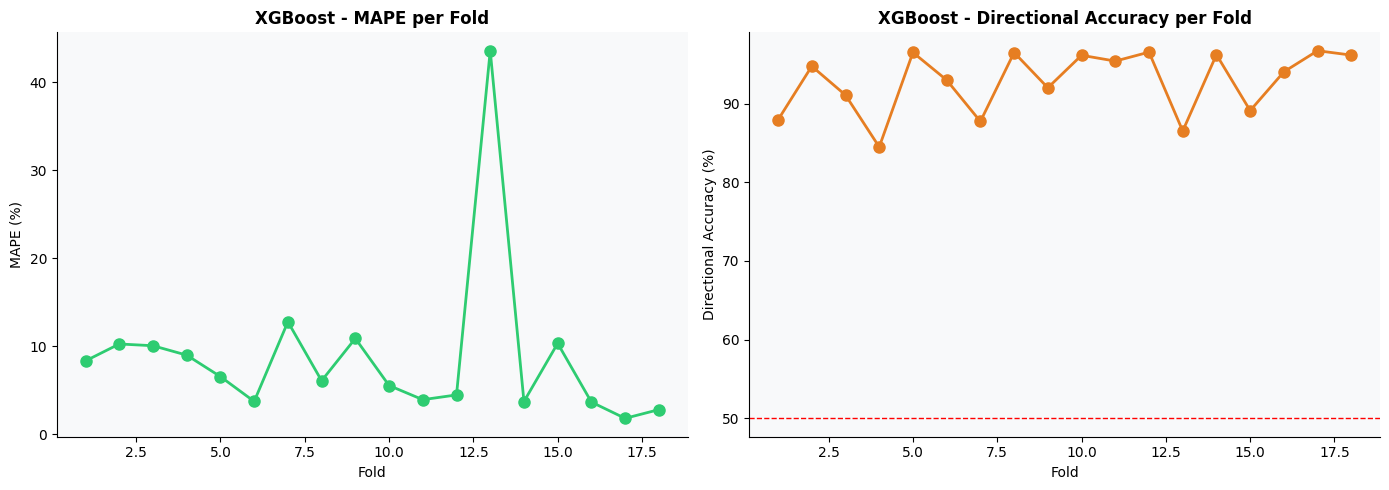

In [33]:
best_folds = results_df[results_df['Model'] == best_model_name].sort_values('Fold')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(best_folds['Fold'], best_folds['MAPE (%)'], marker='o',
             color=SP_GREEN, lw=2, markersize=8)
axes[0].set_title(f'{best_model_name} - MAPE per Fold', fontweight='bold')
axes[0].set_xlabel('Fold'); axes[0].set_ylabel('MAPE (%)')
axes[0].set_facecolor('#F8F9FA')
axes[1].plot(best_folds['Fold'], best_folds['DirAcc (%)'], marker='o',
             color=SP_ACCENT, lw=2, markersize=8)
axes[1].axhline(50, color='red', linestyle='--', lw=1)
axes[1].set_title(f'{best_model_name} - Directional Accuracy per Fold', fontweight='bold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('Directional Accuracy (%)')
axes[1].set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white'); plt.tight_layout()
plt.savefig('viz14_fold_stability.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Phase 10 - Final Model Save and Deployment Notes

The best-performing model across all folds is saved for use in the
FastAPI backend.